# Session 1: Graphs, Laplacians, and where the eigenvectors go

Companion to the slides. Run every cell in order; nothing needs editing until section 7.

## 1. Data

In [5]:
# Colab only. Locally this is a no-op and prints nothing.
# On Colab it installs the spatial stack and downloads the two committed data files.
# On your own machine DATA already points at the repo's data directory, so nothing runs.
import pathlib
import subprocess
import sys
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/farrencc/graph-methods/main"
DATA = pathlib.Path("../data")

if "google.colab" in sys.modules:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "geopandas==1.1.4", "libpysal==4.14.1", "esda==2.9.0", "splot==1.1.7",
         "osmnx==2.1.1", "mapclassify==2.10.0"],
        check=True,
    )
    DATA = pathlib.Path("data")
    DATA.mkdir(exist_ok=True)
    for fname in ("dublin_eds.gpkg", "streets.graphml"):
        urllib.request.urlretrieve(f"{REPO_RAW}/data/{fname}", DATA / fname)
    print("Colab setup done:", sorted(p.name for p in DATA.iterdir()))

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.linalg import eigh

# Fixed seeds: every figure below is reproducible run to run.
# RNG is for anything we draw ourselves, SEED for libraries that want a plain integer.
RNG = np.random.default_rng(20240401)
SEED = 7

# Plot defaults, sized for a projector rather than a laptop screen.
plt.rcParams.update({
    "figure.figsize": (9.0, 5.0),
    "figure.dpi": 110,
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.constrained_layout.use": True,
})

import scipy
print("numpy", np.__version__, "| scipy", scipy.__version__, "| networkx", nx.__version__)
print("data directory:", DATA.resolve())

numpy 2.4.4 | scipy 1.18.0 | networkx 3.6.1
data directory: C:\Users\KnoxA\data


In [7]:
# osmnx is only needed for the street-network cameo in section 6.
# If the import fails, HAVE_OSMNX stays False, that one cell skips itself,
# and nothing else in the notebook is affected.
try:
    import osmnx as ox
    HAVE_OSMNX = True
    print("osmnx", ox.__version__)
except Exception as exc:
    HAVE_OSMNX = False
    print("osmnx unavailable:", exc)

osmnx 2.1.1


## 2. Eigenvector refresher 

$n$ unit masses in a free-free chain of unit springs. $K\mathbf{x} = \lambda \mathbf{x}$.

In [8]:
# n unit masses in a row, joined by unit springs. K is the stiffness matrix:
# assemble it one spring at a time, exactly as you would by hand.
n = 6
K = np.zeros((n, n))
for i, j in [(k, k + 1) for k in range(n - 1)]:
    # one spring, four entries: it stiffens both ends and couples them with a
    # minus sign. Free-free means no spring to ground, so nothing else is added.
    K[i, i] += 1.0
    K[j, j] += 1.0
    K[i, j] -= 1.0
    K[j, i] -= 1.0

print(K.astype(int))

[[ 1 -1  0  0  0  0]
 [-1  2 -1  0  0  0]
 [ 0 -1  2 -1  0  0]
 [ 0  0 -1  2 -1  0]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0  0 -1  1]]


In [9]:
# eigh, not eig: K is symmetric. eig would hand back complex numbers with
# numerical noise in the imaginary part and eigenvectors that are not orthogonal.
# vals comes back sorted ascending; vecs is a matrix whose COLUMNS are the modes.
vals, vecs = eigh(K)

print("eigenvalues:", np.round(vals, 10))
print("mode 0:     ", np.round(vecs[:, 0], 4))

eigenvalues: [0.         0.26794919 1.         2.         3.         3.73205081]
mode 0:      [0.4082 0.4082 0.4082 0.4082 0.4082 0.4082]


In [10]:
# The free-free chain has a closed form: lambda_k = 2 - 2 cos(pi k / n).
# Numerics and algebra should agree to about machine precision.
analytic = 2 - 2 * np.cos(np.pi * np.arange(n) / n)
print(np.column_stack([vals, analytic]).round(8))
print("max |numeric - analytic| =", np.abs(vals - analytic).max())

[[0.         0.        ]
 [0.26794919 0.26794919]
 [1.         1.        ]
 [2.         2.        ]
 [3.         3.        ]
 [3.73205081 3.73205081]]
max |numeric - analytic| = 1.5543122344752192e-15


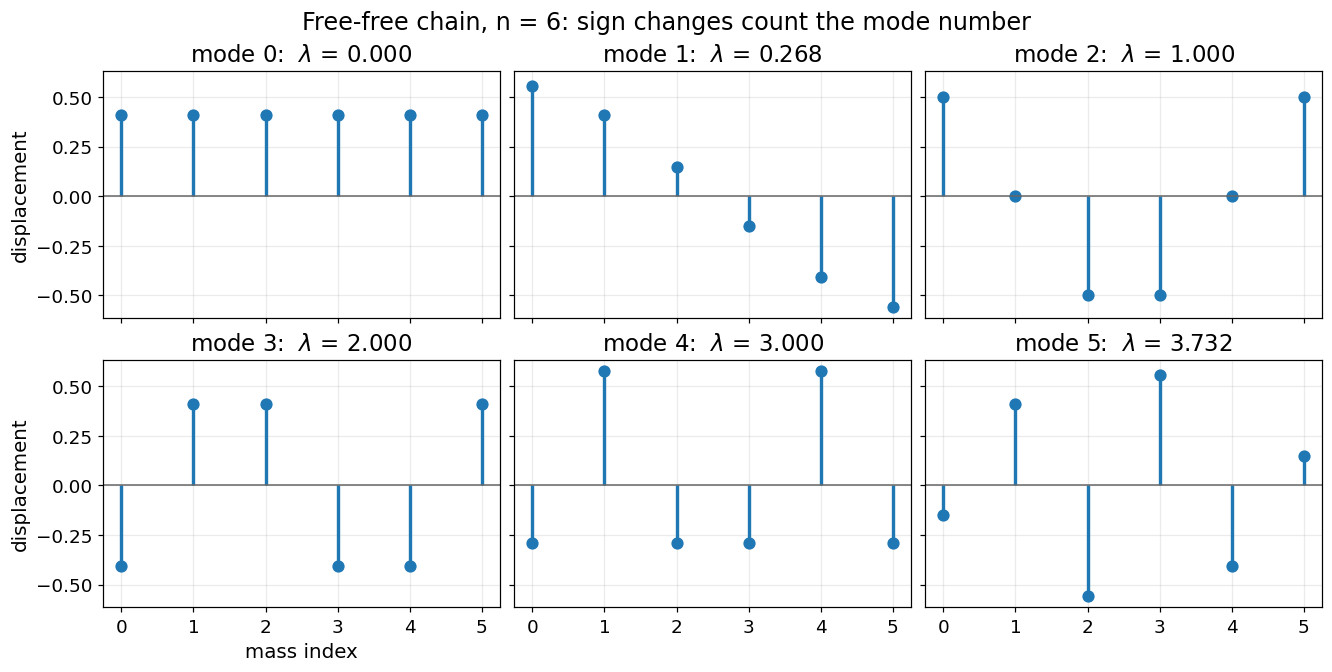

In [11]:
# One panel per mode. Count the sign changes along each stem plot:
# mode k crosses zero k times, which is where the mode number comes from.
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    ax.stem(np.arange(n), vecs[:, k], basefmt=" ")
    ax.axhline(0, color="0.4", lw=1)
    ax.set_title(rf"mode {k}:  $\lambda$ = {vals[k]:.3f}")
axes[1, 0].set_xlabel("mass index")
axes[0, 0].set_ylabel("displacement")
axes[1, 0].set_ylabel("displacement")
fig.suptitle("Free-free chain, n = 6: sign changes count the mode number")
plt.show()

In [12]:
# The eigenvectors are the columns of vecs. The rows are not eigenvectors of anything.
k = 2
print("column vecs[:, k] :", np.abs(K @ vecs[:, k] - vals[k] * vecs[:, k]).max())
print("row    vecs[k, :] :", np.abs(K @ vecs[k, :] - vals[k] * vecs[k, :]).max())

column vecs[:, k] : 3.3306690738754696e-15
row    vecs[k, :] : 1.1969234250586773


In [13]:
# An eigenvector is only defined up to a scale factor, so v and -v are equally valid.
# LAPACK picks one arbitrarily. Never read meaning into the sign on its own.
v = vecs[:, 1]
print("v  residual:", np.abs(K @ v - vals[1] * v).max())
print("-v residual:", np.abs(K @ (-v) - vals[1] * (-v)).max())
print("first entry of v:", v[0], " of -v:", -v[0])

v  residual: 4.468647674116255e-15
-v residual: 4.468647674116255e-15
first entry of v: 0.55767753582521  of -v: -0.55767753582521


Degeneracy: any rotation inside a repeated eigenspace is also an eigenvector, so the
basis LAPACK picks there is arbitrary and will not necessarily be the same on another
machine or another version. The ring below has two pairs of repeated eigenvalues.

In [14]:
# A ring is symmetric under rotation, and that symmetry shows up as repeated eigenvalues.
L_ring = nx.laplacian_matrix(nx.cycle_graph(6)).toarray().astype(float)
print(np.round(eigh(L_ring, eigvals_only=True), 10))

[-0.  1.  1.  3.  3.  4.]


## 3. Laplacian 

$L = D - A$, and $\mathbf{x}^{\top} L \mathbf{x} = \sum_{(i,j) \in E} (x_i - x_j)^2$.

In [15]:
# The spring chain we assembled by hand was a graph Laplacian the whole time.
L_path = nx.laplacian_matrix(nx.path_graph(6)).toarray()
print(L_path)
print("same matrix as the spring chain:", np.array_equal(L_path, K.astype(int)))

[[ 1 -1  0  0  0  0]
 [-1  2 -1  0  0  0]
 [ 0 -1  2 -1  0  0]
 [ 0  0 -1  2 -1  0]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0  0 -1  1]]
same matrix as the spring chain: True


In [16]:
edges = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (3, 5), (4, 5)]
G = nx.Graph(edges)
nodes = list(range(6))

# A: 1 where two nodes share an edge. D: the degrees on the diagonal, zero elsewhere.
# L = D - A is the whole object the rest of the workshop is built on.
A = nx.adjacency_matrix(G, nodelist=nodes).toarray()
D = np.diag(A.sum(axis=1))
L = D - A

print("A =\n", A)
print("degrees =", A.sum(axis=1))
print("L =\n", L)
print("row sums =", L.sum(axis=1))

A =
 [[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]
degrees = [2 2 3 3 2 2]
L =
 [[ 2 -1 -1  0  0  0]
 [-1  2 -1  0  0  0]
 [-1 -1  3 -1  0  0]
 [ 0  0 -1  3 -1 -1]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0 -1 -1  2]]
row sums = [0 0 0 0 0 0]


In [17]:
# The incidence matrix B has one row per edge and one column per node.
# Each row is all zeros apart from a -1 at the tail and a +1 at the head.
edge_list = sorted(tuple(sorted(e)) for e in G.edges())
B = np.zeros((len(edge_list), len(nodes)))
for e, (i, j) in enumerate(edge_list):
    B[e, i] = -1.0   # tail
    B[e, j] = +1.0   # head
    # the head/tail choice is bookkeeping. The graph is undirected; we are
    # picking an orientation only so that a difference has a sign.

print("edges:", edge_list)
print(B.astype(int))

edges: [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (3, 5), (4, 5)]
[[-1  1  0  0  0  0]
 [-1  0  1  0  0  0]
 [ 0 -1  1  0  0  0]
 [ 0  0 -1  1  0  0]
 [ 0  0  0 -1  1  0]
 [ 0  0  0 -1  0  1]
 [ 0  0  0  0 -1  1]]


In [18]:
# B @ x is therefore the list of differences of x across the edges.
x = np.array([3.0, 1.0, 4.0, 1.0, 5.0, 9.0])
for (i, j), d in zip(edge_list, B @ x):
    print(f"edge ({i},{j}):  x[{j}] - x[{i}] = {d:+.0f}")

edge (0,1):  x[1] - x[0] = -2
edge (0,2):  x[2] - x[0] = +1
edge (1,2):  x[2] - x[1] = +3
edge (2,3):  x[3] - x[2] = -3
edge (3,4):  x[4] - x[3] = +4
edge (3,5):  x[5] - x[3] = +8
edge (4,5):  x[5] - x[4] = +4


In [19]:
# B^T B reproduces L exactly, which is the factorisation the next cell relies on.
print("B^T B == D - A                :", np.array_equal(B.T @ B, L))
print("B^T B == nx.laplacian_matrix  :",
      np.array_equal(B.T @ B, nx.laplacian_matrix(G, nodelist=nodes).toarray()))

B^T B == D - A                : True
B^T B == nx.laplacian_matrix  : True


In [20]:
# x^T L x = ||B x||^2 = the sum of squared differences across every edge.
# This is the quantity every cut and every clustering below is minimising.
print("x^T L x        =", x @ L @ x)
print("||B x||^2      =", np.sum((B @ x) ** 2))
print("sum (xi - xj)^2 =", sum((x[i] - x[j]) ** 2 for i, j in edge_list))

x^T L x        = 119.0
||B x||^2      = 119.0
sum (xi - xj)^2 = 119.0


In [21]:
# Reverse the orientation of two edges. B changes; B^T B does not.
# The arbitrary head/tail choice never reaches the Laplacian.
B_flipped = B.copy()
B_flipped[[0, 4]] *= -1

print("B changed        :", not np.array_equal(B_flipped, B))
print("B^T B unchanged  :", np.array_equal(B_flipped.T @ B_flipped, L))

B changed        : True
B^T B unchanged  : True


In [22]:
# Feed L a vector of +1 / -1 labels and the quadratic form counts the cut edges:
# each cut edge contributes (1 - (-1))^2 = 4, so s^T L s = 4 x cut.
for s in [np.array([1.0, 1.0, 1.0, -1.0, -1.0, -1.0]),
          np.array([1.0, -1.0, 1.0, -1.0, 1.0, -1.0])]:
    cut = sum(1 for i, j in edge_list if s[i] != s[j])
    print(f"s = {s.astype(int)}   s^T L s = {s @ L @ s:5.0f}   4 x cut = {4 * cut:5d}")

s = [ 1  1  1 -1 -1 -1]   s^T L s =     4   4 x cut =     4
s = [ 1 -1  1 -1  1 -1]   s^T L s =    20   4 x cut =    20


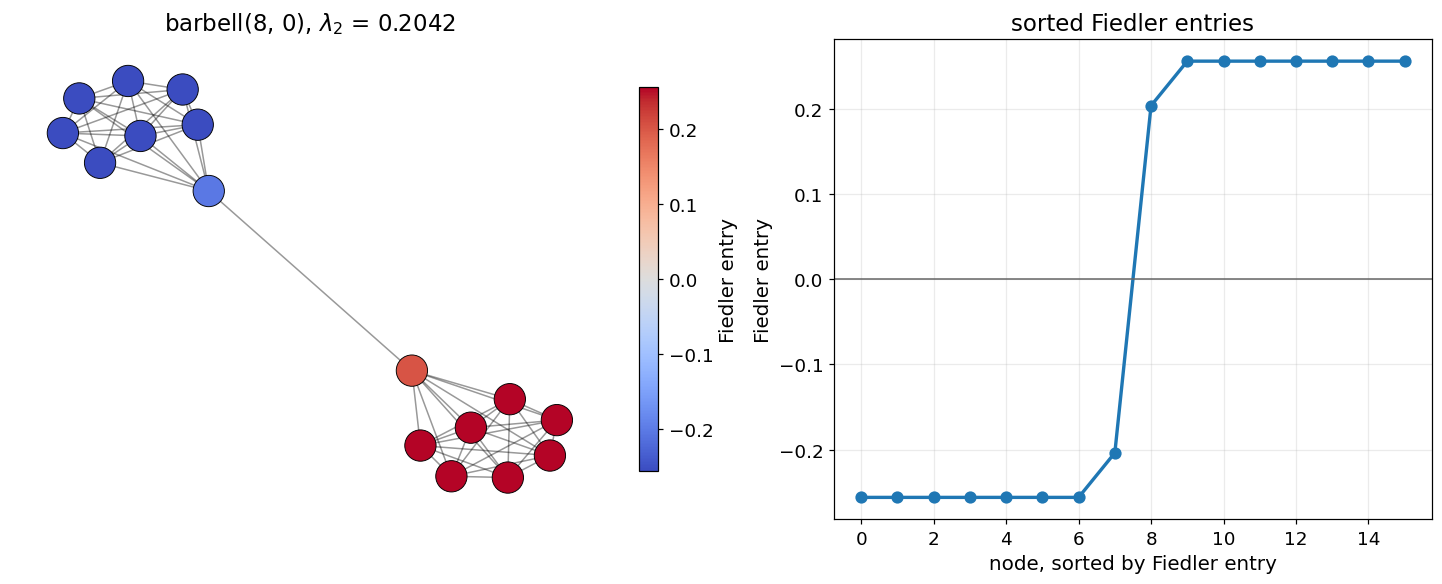

In [23]:
# Two cliques joined by a single edge: the clearest possible bottleneck.
Gb = nx.barbell_graph(8, 0)
Lb = nx.laplacian_matrix(Gb).toarray().astype(float)
vals_b, vecs_b = eigh(Lb)
# The Fiedler vector is the eigenvector of the SECOND smallest eigenvalue.
# The first is always 0 with a constant eigenvector and tells you nothing.
fiedler = vecs_b[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
pos = nx.spring_layout(Gb, seed=SEED)
nx.draw_networkx_edges(Gb, pos, ax=ax1, alpha=0.4)
sc = nx.draw_networkx_nodes(Gb, pos, ax=ax1, node_color=fiedler, cmap="coolwarm",
                            node_size=420, edgecolors="k", linewidths=0.6)
ax1.set_axis_off()
ax1.set_title(rf"barbell(8, 0), $\lambda_2$ = {vals_b[1]:.4f}")
fig.colorbar(sc, ax=ax1, shrink=0.8, label="Fiedler entry")

ax2.plot(np.sort(fiedler), "o-")
ax2.axhline(0, color="0.4", lw=1)
ax2.set_xlabel("node, sorted by Fiedler entry")
ax2.set_ylabel("Fiedler entry")
ax2.set_title("sorted Fiedler entries")
plt.show()

In [24]:
# lambda_2 (algebraic connectivity) as a single number for how hard the graph is to split.
for name, g in [
    ("barbell(8,0)", nx.barbell_graph(8, 0)),
    ("path(16)", nx.path_graph(16)),
    ("ring(16)", nx.cycle_graph(16)),
    ("complete(16)", nx.complete_graph(16)),
]:
    lam = eigh(nx.laplacian_matrix(g).toarray().astype(float), eigvals_only=True)
    print(f"{name:14s}  lambda_2 = {lam[1]:8.4f}")

barbell(8,0)    lambda_2 =   0.2042
path(16)        lambda_2 =   0.0384
ring(16)        lambda_2 =   0.1522
complete(16)    lambda_2 =  16.0000


## 4. Spectral clustering

$\mathrm{RatioCut}(A,\bar A) = \mathrm{cut}\left(\tfrac{1}{|A|} + \tfrac{1}{|\bar A|}\right)$,
$\;\mathrm{Ncut}(A,\bar A) = \mathrm{cut}\left(\tfrac{1}{\mathrm{vol}\,A} + \tfrac{1}{\mathrm{vol}\,\bar A}\right)$.

In [25]:
# A big clique, a small clique, three bridge edges between them, plus one pendant
# node hanging off the big clique by a single edge. The minimum cut is that pendant
# edge, which is exactly the split nobody wants.
N_BIG, N_SMALL, N_BRIDGE = 12, 4, 3

big = list(range(N_BIG))
small = list(range(N_BIG, N_BIG + N_SMALL))
PENDANT = N_BIG + N_SMALL

Gp = nx.Graph()
Gp.add_edges_from(nx.complete_graph(big).edges())
Gp.add_edges_from(nx.complete_graph(small).edges())
for k in range(N_BRIDGE):
    Gp.add_edge(big[-1 - k], small[k])
Gp.add_edge(big[0], PENDANT)

min_cut = nx.minimum_edge_cut(Gp)
torn = Gp.copy()
torn.remove_edges_from(min_cut)

print("minimum edge cut:", sorted(min_cut))
print("component sizes :", sorted(len(c) for c in nx.connected_components(torn)))

minimum edge cut: [(16, 0)]
component sizes : [1, 16]


In [26]:
# Three scores for the same split: the raw cut, RatioCut (penalised by node counts)
# and Ncut (penalised by volume, meaning summed degree).
def cut_scores(g, side):
    side = set(side)
    other = set(g) - side
    cut = sum(1 for i, j in g.edges() if (i in side) != (j in side))
    vol_s = sum(d for _, d in g.degree(side))
    vol_o = sum(d for _, d in g.degree(other))
    return cut, cut * (1 / len(side) + 1 / len(other)), cut * (1 / vol_s + 1 / vol_o)


print(f"{'split':>16s} {'cut':>5s} {'RatioCut':>10s} {'Ncut':>10s}")
for label, side in [("pendant alone", [PENDANT]), ("at the bridge", small)]:
    c, rc, nc = cut_scores(Gp, side)
    print(f"{label:>16s} {c:5d} {rc:10.3f} {nc:10.4f}")

           split   cut   RatioCut       Ncut
   pendant alone     1      1.062     1.0066
   at the bridge     3      0.981     0.2219


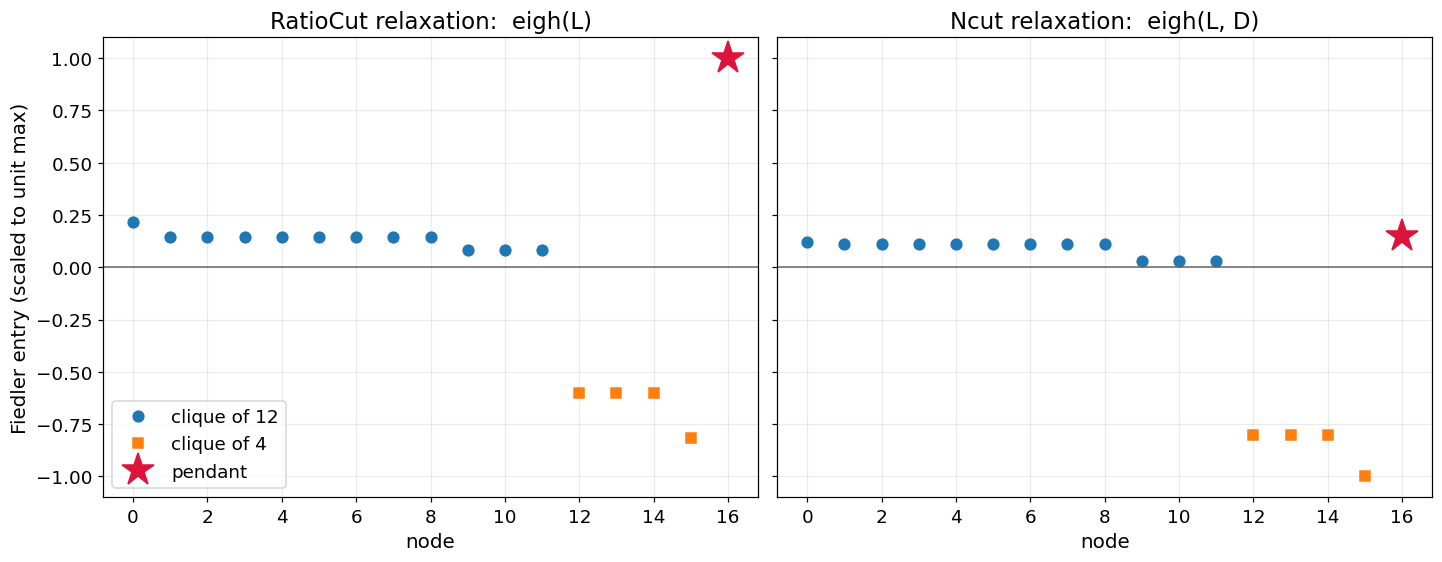

In [27]:
Lp = nx.laplacian_matrix(Gp, nodelist=sorted(Gp)).toarray().astype(float)
Dp = np.diag([Gp.degree(v) for v in sorted(Gp)]).astype(float)

# The two relaxations differ by one argument: eigh(L) relaxes RatioCut,
# eigh(L, D) solves the generalised problem L v = lambda D v and relaxes Ncut.
f_ratio = eigh(Lp)[1][:, 1]
f_ncut = eigh(Lp, Dp)[1][:, 1]

# both are defined up to sign and scale; fix both so the panels are comparable
f_ratio = f_ratio / np.abs(f_ratio).max() * np.sign(f_ratio[PENDANT])
f_ncut = f_ncut / np.abs(f_ncut).max() * np.sign(f_ncut[PENDANT])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, f, title in [(axes[0], f_ratio, "RatioCut relaxation:  eigh(L)"),
                     (axes[1], f_ncut, "Ncut relaxation:  eigh(L, D)")]:
    ax.plot(big, f[big], "o", label=f"clique of {N_BIG}")
    ax.plot(small, f[small], "s", label=f"clique of {N_SMALL}")
    ax.plot([PENDANT], [f[PENDANT]], "*", ms=22, color="crimson", label="pendant")
    ax.axhline(0, color="0.4", lw=1)
    ax.set_xlabel("node")
    ax.set_title(title)
axes[0].set_ylabel("Fiedler entry (scaled to unit max)")
axes[0].legend(loc="lower left")
plt.show()

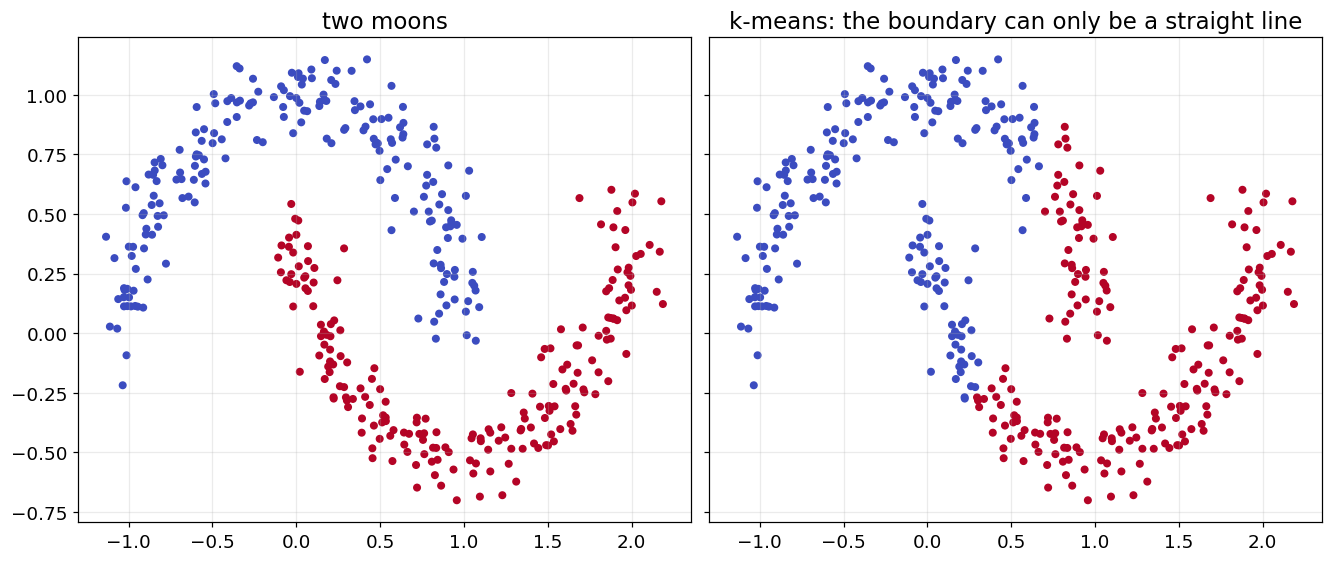

In [28]:
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import make_moons

# Two interleaving crescents: the clusters are obvious to the eye and
# impossible for any method that separates them with a straight boundary.
X, y_true = make_moons(n_samples=400, noise=0.10, random_state=SEED)
y_km = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
ax1.scatter(*X.T, c=y_true, cmap="coolwarm", s=18)
ax1.set_title("two moons")
ax2.scatter(*X.T, c=y_km, cmap="coolwarm", s=18)
ax2.set_title("k-means: the boundary can only be a straight line")
plt.show()

In [29]:
from sklearn.neighbors import kneighbors_graph

K_NN = 12
k = 2

# kNN is not a symmetric relation: i can be among j's ten nearest without j
# being among i's. Symmetrise before calling it an adjacency matrix, or L is
# not symmetric and eigh is meaningless.
Aknn = kneighbors_graph(X, K_NN, mode="connectivity", include_self=False).toarray()
Aknn = np.maximum(Aknn, Aknn.T)

# From here it is the same three steps as the barbell: build L, take the
# bottom k eigenvectors, and run k-means on those coordinates instead of the originals.
Dm = np.diag(Aknn.sum(axis=1))
Lm = Dm - Aknn
vals_m, vecs_m = eigh(Lm, Dm)
U = vecs_m[:, :k]
y_spec = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(U)

print("kNN graph connected:", nx.is_connected(nx.from_numpy_array(Aknn)))
print("first eigenvalues:", np.round(vals_m[:5], 6))

kNN graph connected: True
first eigenvalues: [-0.        0.000405  0.003274  0.004238  0.012788]


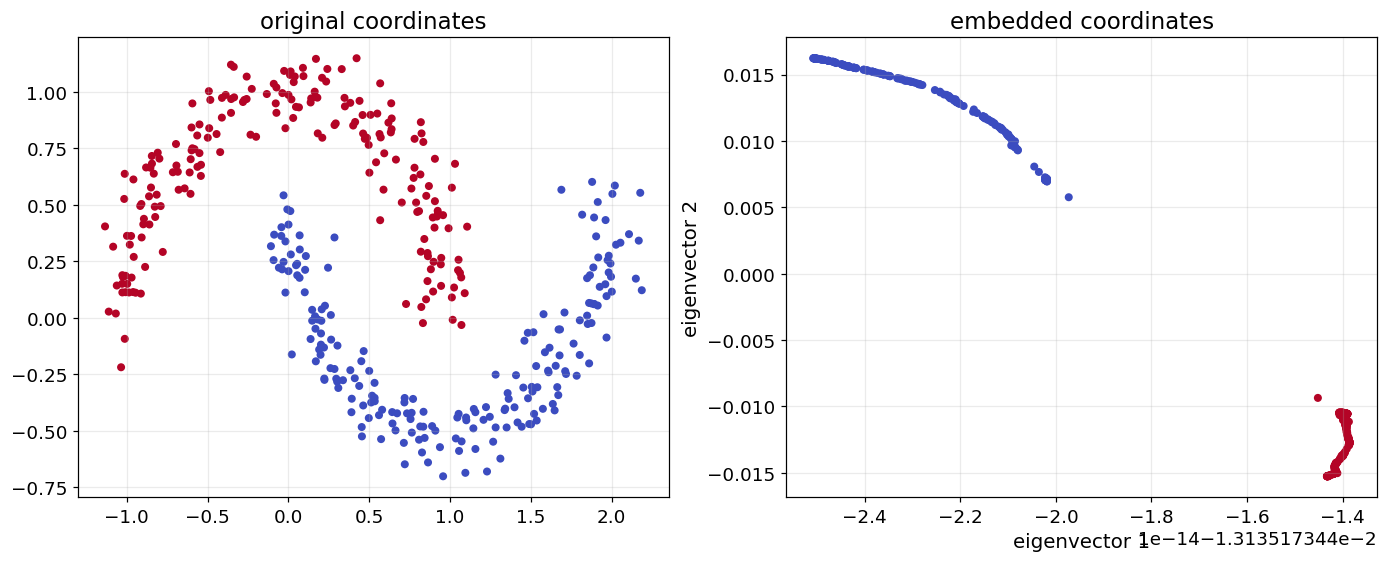

In [30]:
# Left: the labels drawn back on the original data. Right: the same points in the
# two eigenvector coordinates, where each crescent has collapsed to a single blob.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
ax1.scatter(*X.T, c=y_spec, cmap="coolwarm", s=18)
ax1.set_title("original coordinates")
ax2.scatter(U[:, 0], U[:, 1], c=y_spec, cmap="coolwarm", s=18)
ax2.set_xlabel("eigenvector 1")
ax2.set_ylabel("eigenvector 2")
ax2.set_title("embedded coordinates")
plt.show()

C:\Users\KnoxA\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


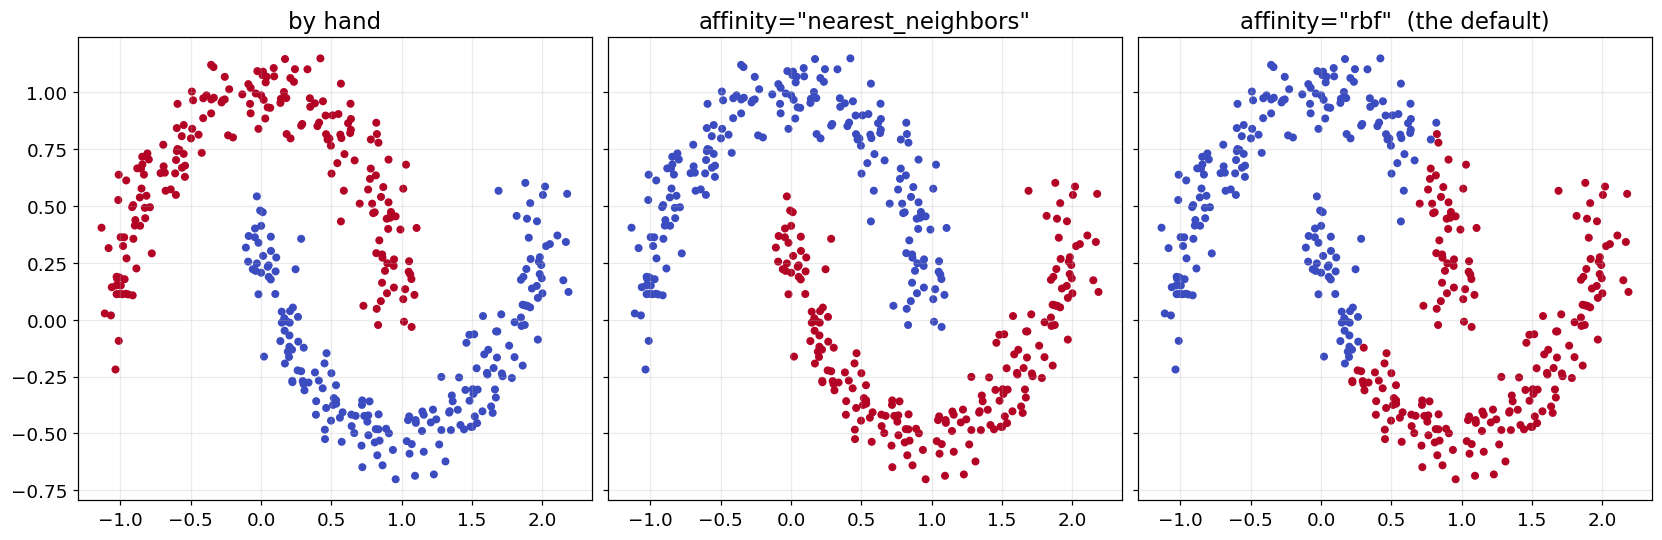

In [31]:
# The same thing from the library. Note the default affinity is "rbf", not kNN,
# and on this data it is the affinity choice that decides whether the answer is right.
y_nn = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                          n_neighbors=K_NN, random_state=SEED,
                          assign_labels="kmeans").fit_predict(X)
y_rbf = SpectralClustering(n_clusters=2, affinity="rbf",
                           random_state=SEED, assign_labels="kmeans").fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, lab, title in [(axes[0], y_spec, "by hand"),
                       (axes[1], y_nn, 'affinity="nearest_neighbors"'),
                       (axes[2], y_rbf, 'affinity="rbf"  (the default)')]:
    ax.scatter(*X.T, c=lab, cmap="coolwarm", s=18)
    ax.set_title(title)
plt.show()

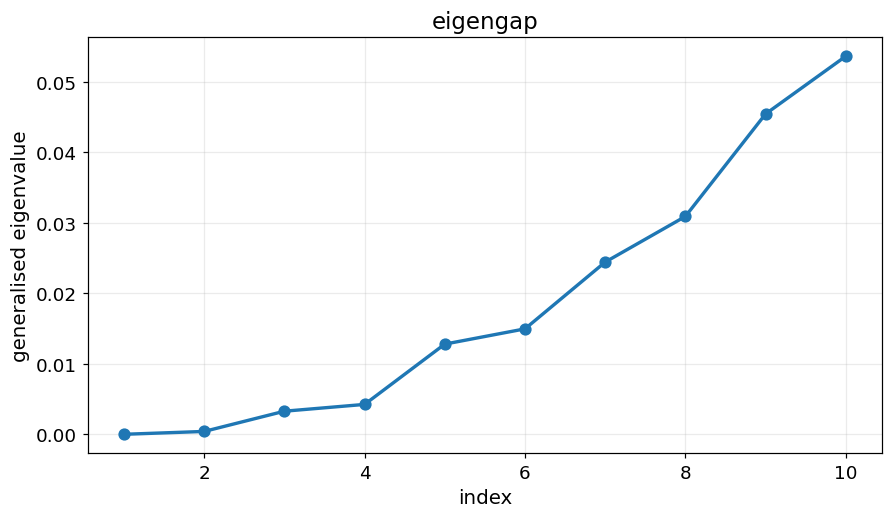

In [32]:
# Where the eigenvalues jump is a rough suggestion of how many clusters to ask for.
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(np.arange(1, 11), vals_m[:10], "o-")
ax.set_xlabel("index")
ax.set_ylabel("generalised eigenvalue")
ax.set_title("eigengap")
plt.show()

## 5. Community detection

In [33]:
# A planted block model: two large blocks, plus a sparse third block wired to both.
# The third block is built to behave like a border region rather than a community.
SIZES = [60, 60, 20]
P_IN, P_CROSS, P_BORDER_OUT, P_BORDER_IN = 0.20, 0.004, 0.12, 0.02

P = [[P_IN, P_CROSS, P_BORDER_OUT],
     [P_CROSS, P_IN, P_BORDER_OUT],
     [P_BORDER_OUT, P_BORDER_OUT, P_BORDER_IN]]

Gsbm = nx.stochastic_block_model(SIZES, P, seed=SEED)
planted = np.concatenate([np.full(s, b) for b, s in enumerate(SIZES)])

# Louvain maximises modularity greedily. It has no way to report "this is a border":
# every node must be assigned to exactly one community.
communities = nx.community.louvain_communities(Gsbm, seed=SEED)
detected = np.empty(len(planted), dtype=int)
for c, members in enumerate(communities):
    detected[list(members)] = c

border = np.bincount(detected[planted == 2], minlength=len(communities))
print(f"communities found : {len(communities)}  sizes {sorted(len(c) for c in communities)}")
print(f"modularity        : {nx.community.modularity(Gsbm, communities):.3f}")
print(f"border block of {SIZES[2]} landed in : {dict(enumerate(border))}")

communities found : 2  sizes [70, 70]
modularity        : 0.385
border block of 20 landed in : {0: np.int64(10), 1: np.int64(10)}


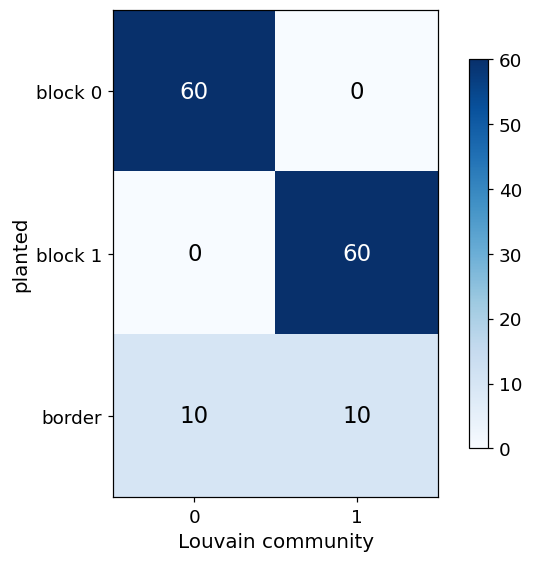

In [34]:
# Confusion matrix: planted block down the side, Louvain community across the top.
conf = np.zeros((len(SIZES), len(communities)), dtype=int)
for p, d in zip(planted, detected):
    conf[p, d] += 1

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(conf, cmap="Blues")
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        ax.text(j, i, conf[i, j], ha="center", va="center",
                color="white" if conf[i, j] > conf.max() / 2 else "black", fontsize=15)
ax.set_xticks(range(conf.shape[1]))
ax.set_yticks(range(conf.shape[0]), ["block 0", "block 1", "border"])
ax.set_xlabel("Louvain community")
ax.set_ylabel("planted")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

In [35]:
Ls = nx.laplacian_matrix(Gsbm, nodelist=sorted(Gsbm)).toarray().astype(float)
Ds = np.diag([Gsbm.degree(v) for v in sorted(Gsbm)]).astype(float)
f_sbm = eigh(Ls, Ds)[1][:, 1]
# The spectral split of the same graph, for comparison: sign of the Ncut Fiedler vector.
ncut_labels = (f_sbm > 0).astype(int)

agree = np.array([[np.sum((detected == c) & (ncut_labels == d))
                   for d in (0, 1)] for c in range(len(communities))])
print("Louvain (rows) against the Ncut sign split (columns):")
print(agree)

Louvain (rows) against the Ncut sign split (columns):
[[ 3 67]
 [68  2]]


## 6. Geospatial

In [36]:
import geopandas as gpd
from libpysal.weights import Queen, Rook

ATTR = "pct_third_level"

# 162 Electoral Divisions of Dublin City, CSO 2022 boundaries.
# EPSG:2157 is Irish Transverse Mercator, in metres. Centroids and distances taken in
# lat/lon would be angles, not lengths, and would be quietly wrong.
gdf = gpd.read_file(DATA / "dublin_eds.gpkg", layer="eds")
print("CRS on disk :", gdf.crs.to_string(), "-", gdf.crs.name)
gdf = gdf.to_crs(2157)
print("CRS in use  :", gdf.crs.to_string(), "-", gdf.crs.name)
print(f"{len(gdf)} electoral divisions, {ATTR} from {gdf[ATTR].min():.1f} to {gdf[ATTR].max():.1f}")

CRS on disk : EPSG:2157 - IRENET95 / Irish Transverse Mercator
CRS in use  : EPSG:2157 - IRENET95 / Irish Transverse Mercator
162 electoral divisions, pct_third_level from 9.2 to 85.6


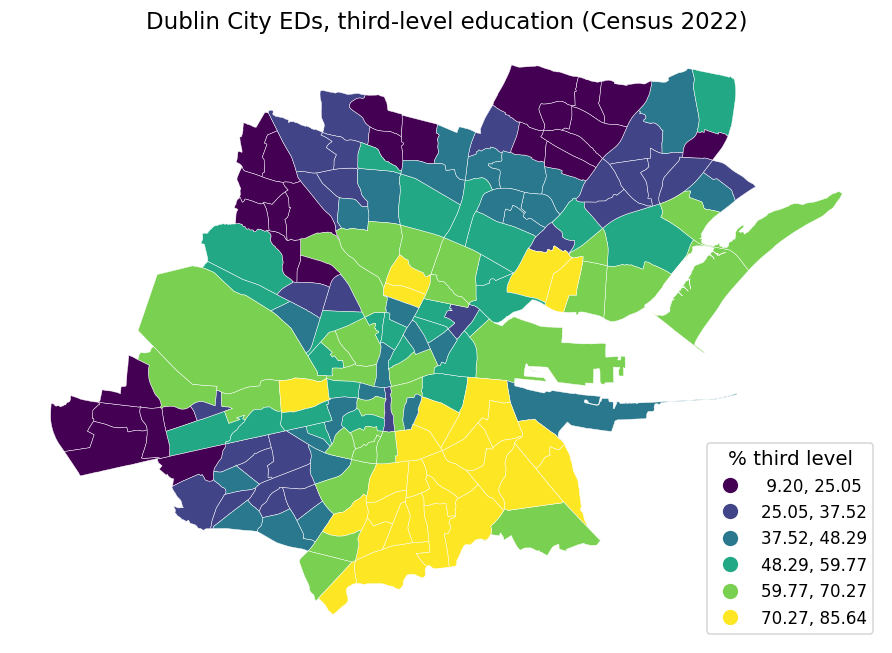

In [37]:
# The attribute on its own, before any graph is involved.
fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column=ATTR, cmap="viridis", scheme="quantiles", k=6,
         legend=True, edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"title": "% third level", "loc": "lower right", "fontsize": 11})
ax.set_axis_off()
ax.set_title("Dublin City EDs, third-level education (Census 2022)")
plt.show()

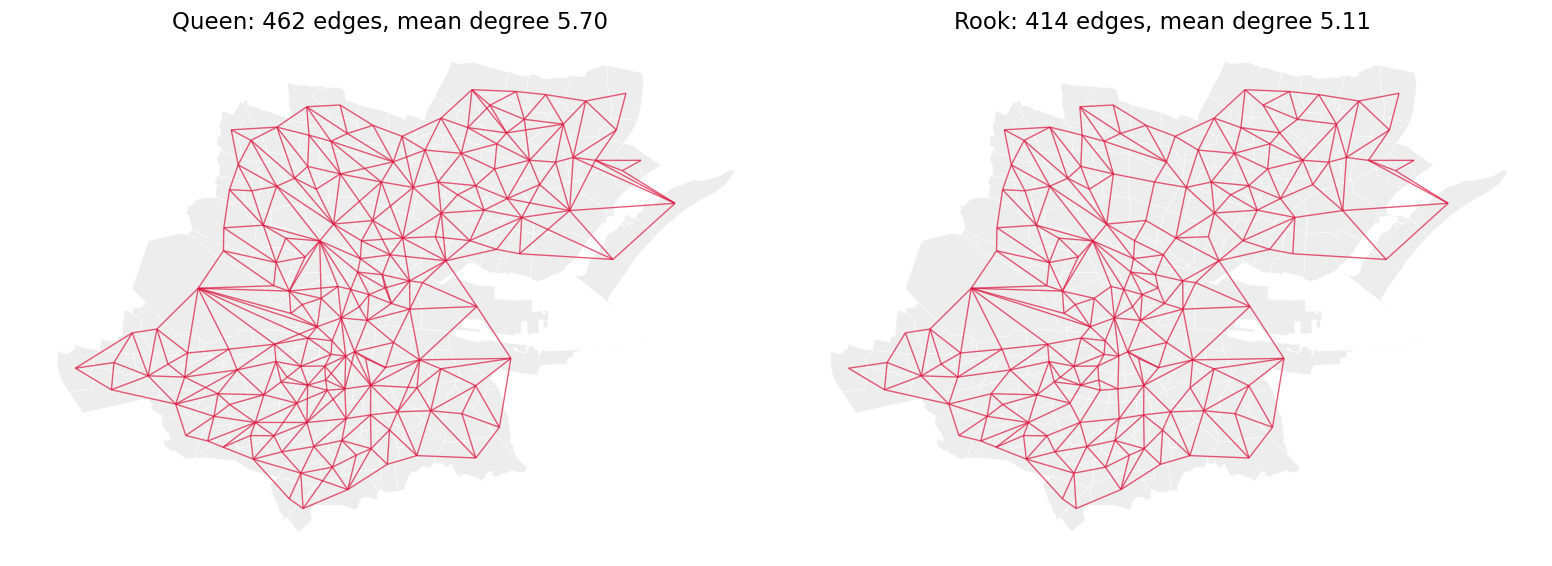

In [38]:
# Contiguity turns a map into a graph. Queen: an edge if two EDs share any boundary
# point at all, corners included. Rook: an edge only if they share a boundary segment.
w_queen = Queen.from_dataframe(gdf, use_index=False)
w_rook = Rook.from_dataframe(gdf, use_index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
for ax, w, name in [(axes[0], w_queen, "Queen"), (axes[1], w_rook, "Rook")]:
    g = w.to_networkx()
    pts = {i: (p.x, p.y) for i, p in enumerate(gdf.geometry.representative_point())}
    gdf.plot(ax=ax, color="0.93", edgecolor="white", linewidth=0.3)
    nx.draw_networkx_edges(g, pts, ax=ax, edge_color="crimson", width=0.9, alpha=0.7)
    ax.set_axis_off()
    deg = np.mean([d for _, d in g.degree()])
    ax.set_title(f"{name}: {g.number_of_edges()} edges, mean degree {deg:.2f}")
plt.show()

In [39]:
# Build the graph the rest of the day runs on, carrying the census attribute,
# the map position and the ED name along on the nodes.
G_ed = w_queen.to_networkx()
G_ed = nx.relabel_nodes(G_ed, {i: i for i in range(len(gdf))})

pts = gdf.geometry.representative_point()
POS = {i: (pts.iloc[i].x, pts.iloc[i].y) for i in range(len(gdf))}
nx.set_node_attributes(G_ed, dict(zip(range(len(gdf)), gdf[ATTR])), ATTR)
nx.set_node_attributes(G_ed, POS, "pos")
nx.set_node_attributes(G_ed, dict(zip(range(len(gdf)), gdf["ED_ENGLISH"])), "name")

assert list(G_ed.nodes()) == list(range(len(gdf))), "node order must match gdf row order"
print("nodes:", G_ed.number_of_nodes(), " edges:", G_ed.number_of_edges())
print("connected:", nx.is_connected(G_ed))
print("spot check:", [(i, G_ed.nodes[i]["name"], gdf["ED_ENGLISH"].iloc[i]) for i in (0, 80, 161)])

nodes: 162  edges: 462
connected: True
spot check: [(0, 'ARRAN QUAY A', 'ARRAN QUAY A'), (80, 'INNS QUAY B', 'INNS QUAY B'), (161, 'WOOD QUAY B', 'WOOD QUAY B')]


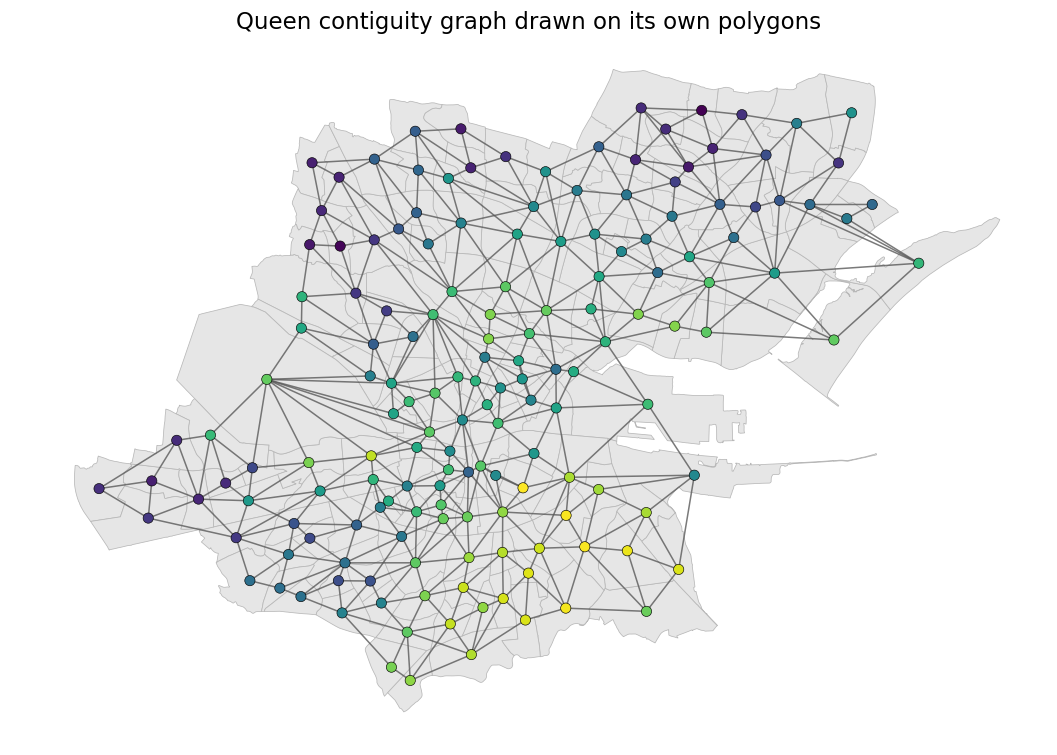

In [40]:
# Same 162 objects drawn twice over: polygons underneath, nodes and edges on top.
fig, ax = plt.subplots(figsize=(9.5, 10.5))
gdf.plot(ax=ax, color="0.90", edgecolor="0.72", linewidth=0.5)
nx.draw_networkx_edges(G_ed, POS, ax=ax, edge_color="0.35", width=1.0, alpha=0.8)
nx.draw_networkx_nodes(G_ed, POS, ax=ax, node_size=45,
                       node_color=gdf[ATTR], cmap="viridis",
                       edgecolors="k", linewidths=0.4)
ax.set_axis_off()
ax.set_title("Queen contiguity graph drawn on its own polygons")
plt.show()

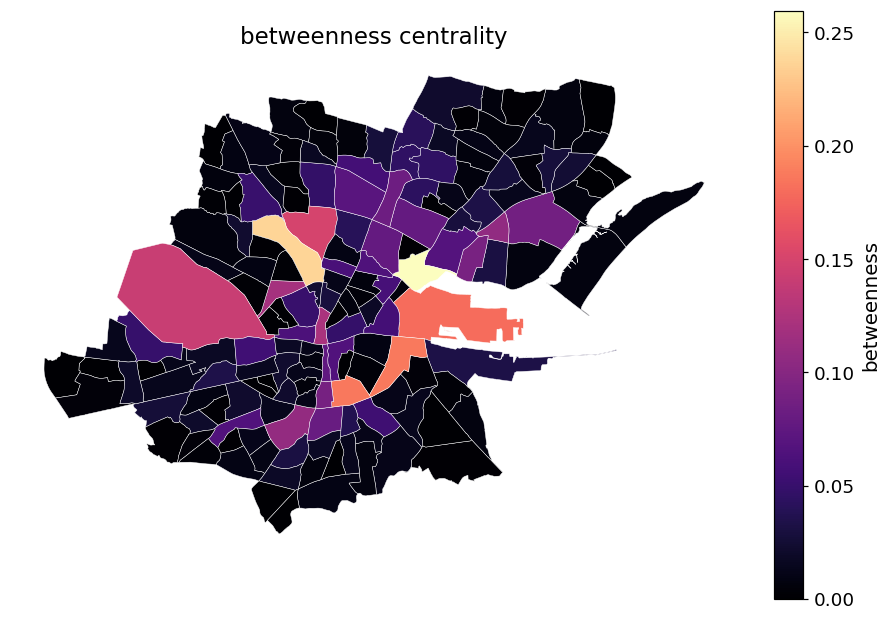

In [41]:
# Betweenness: the fraction of shortest paths through each ED. High values pick out
# the places the graph has to route through, which here means bridges and narrow necks.
gdf["betweenness"] = list(nx.betweenness_centrality(G_ed).values())

fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column="betweenness", cmap="magma", legend=True,
         edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"shrink": 0.6, "label": "betweenness"})
ax.set_axis_off()
ax.set_title("betweenness centrality")
plt.show()

lambda_1 = 6.55e-16  lambda_2 = 0.06089


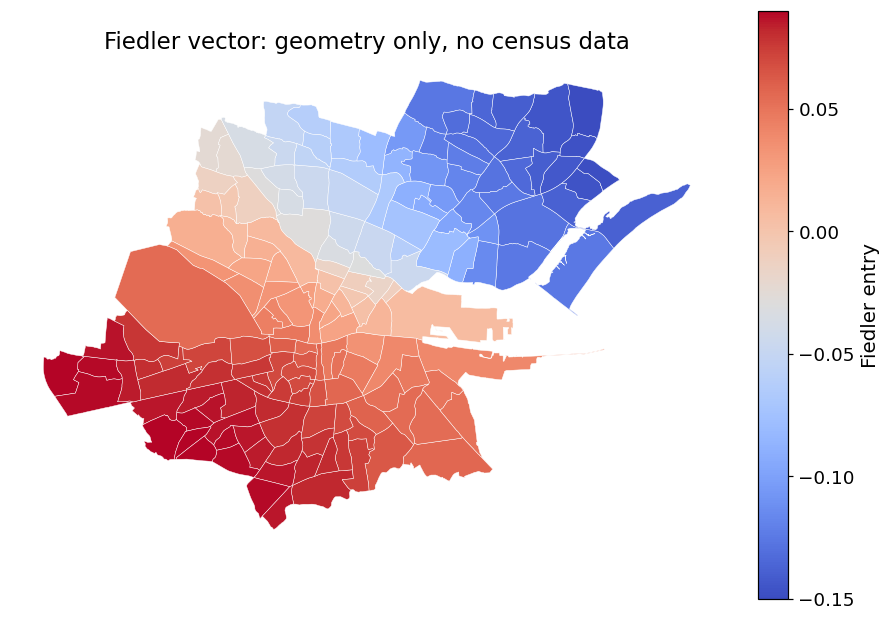

In [42]:
# The same Fiedler calculation as the barbell, now on the real map.
# No census data has been used yet: this split comes from the shapes alone.
L_ed = nx.laplacian_matrix(G_ed, nodelist=range(len(gdf))).toarray().astype(float)
vals_ed, vecs_ed = eigh(L_ed)
gdf["fiedler"] = vecs_ed[:, 1]

print("lambda_1 =", f"{vals_ed[0]:.2e}", " lambda_2 =", f"{vals_ed[1]:.5f}")

fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column="fiedler", cmap="coolwarm", legend=True,
         edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"shrink": 0.6, "label": "Fiedler entry"})
ax.set_axis_off()
ax.set_title(r"Fiedler vector: geometry only, no census data")
plt.show()

414 nodes, 909 edges


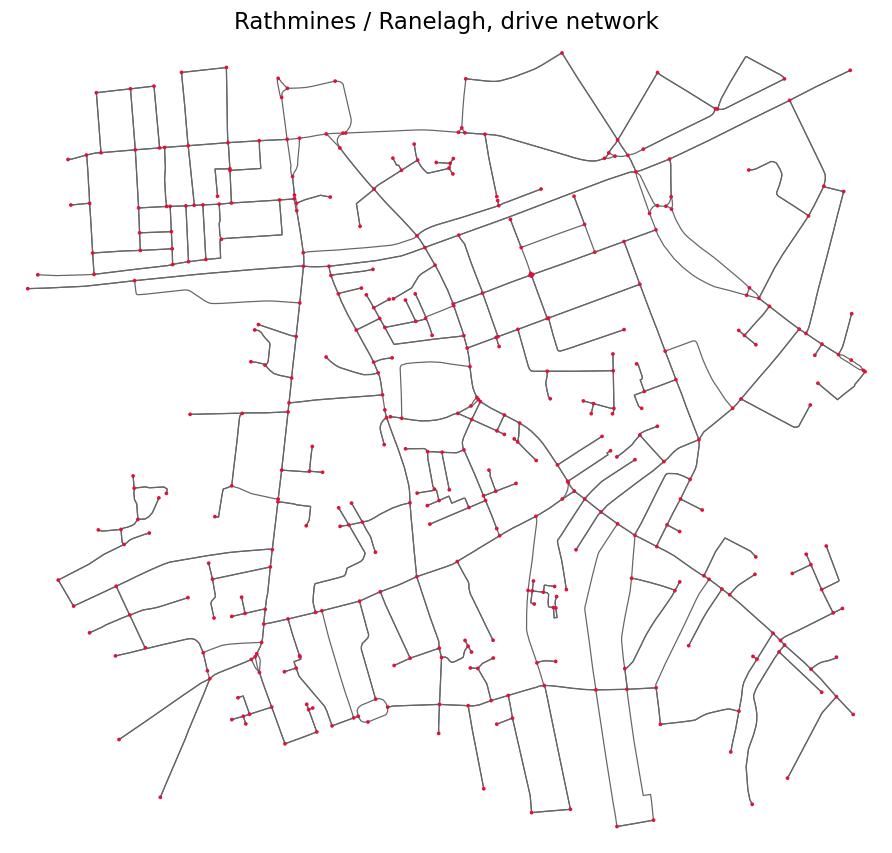

In [43]:
# A different kind of graph over the same city: junctions as nodes, roads as edges.
if HAVE_OSMNX:
    streets = ox.load_graphml(DATA / "streets.graphml")
    print(f"{streets.number_of_nodes()} nodes, {streets.number_of_edges()} edges")
    fig, ax = ox.plot_graph(streets, node_size=6, edge_linewidth=0.8,
                            bgcolor="white", node_color="crimson",
                            edge_color="0.4", figsize=(8, 8), show=False, close=False)
    ax.set_title("Rathmines / Ranelagh, drive network")
    plt.show()
else:
    print("skipped: osmnx did not import")

## 7. Applied: weighted clustering

$w_{ij} = \exp\!\left(-\dfrac{(x_i - x_j)^2}{2\sigma^2}\right)$ on the contiguity edges.
The weight is a similarity. It goes to 1 when two neighbouring EDs report almost the
same value and towards 0 when they differ. Flip the sign inside the exponent and you get
a distance instead: the map still comes out looking plausible, and everything you read
off it is wrong.

In [44]:
from scipy.stats import skew

# Standardise the attribute before it becomes an edge weight, so that SIGMA below
# is measured in standard deviations and not in percentage points.
raw = gdf[ATTR].to_numpy(float)
print(f"skew of {ATTR}: {skew(raw):+.2f}")

# a log transform here would fight a distribution that is already symmetric
values = raw if abs(skew(raw)) < 1.0 else np.log1p(raw)
z = (values - values.mean()) / values.std(ddof=0)
print(f"standardised: mean {z.mean():+.2e}, sd {z.std(ddof=0):.3f}")

skew of pct_third_level: -0.03
standardised: mean +0.00e+00, sd 1.000


|z_i - z_j| across 462 contiguity edges
  10th percentile : 0.076
  25th percentile : 0.180
  50th percentile : 0.428
  75th percentile : 0.796
  90th percentile : 1.334
  max             : 2.211


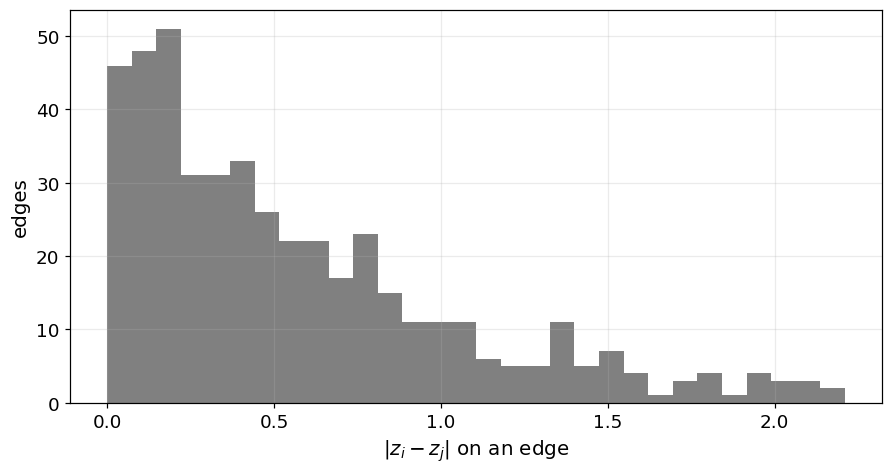

In [45]:
# How different are neighbouring EDs, in standardised units? These are the numbers
# SIGMA has to be chosen against, so look at their spread before choosing it.
diffs = np.array([abs(z[i] - z[j]) for i, j in G_ed.edges()])
print(f"|z_i - z_j| across {len(diffs)} contiguity edges")
for q in (10, 25, 50, 75, 90):
    print(f"  {q:2d}th percentile : {np.percentile(diffs, q):.3f}")
print(f"  max             : {diffs.max():.3f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(diffs, bins=30, color="0.5")
ax.set_xlabel(r"$|z_i - z_j|$ on an edge")
ax.set_ylabel("edges")
plt.show()

In [46]:
# ===========================================================================
# CHANGE THIS AND RE-RUN. Everything below follows from it.
#
# SIGMA is the scale on which two neighbouring EDs count as "similar". Large SIGMA:
# every weight is near 1 and you are back to pure geography. Small SIGMA: every weight
# is near 0 and the graph falls apart. The median edge difference is a sane starting
# point, not a correct answer.
SIGMA = float(np.median(diffs))
# ===========================================================================
print(f"SIGMA = {SIGMA:.3f}  (the median edge difference)")

SIGMA = 0.428  (the median edge difference)


edge weights: min 1.57e-06, median 0.607, max 1.000
lambda_2 = 5.433e-03


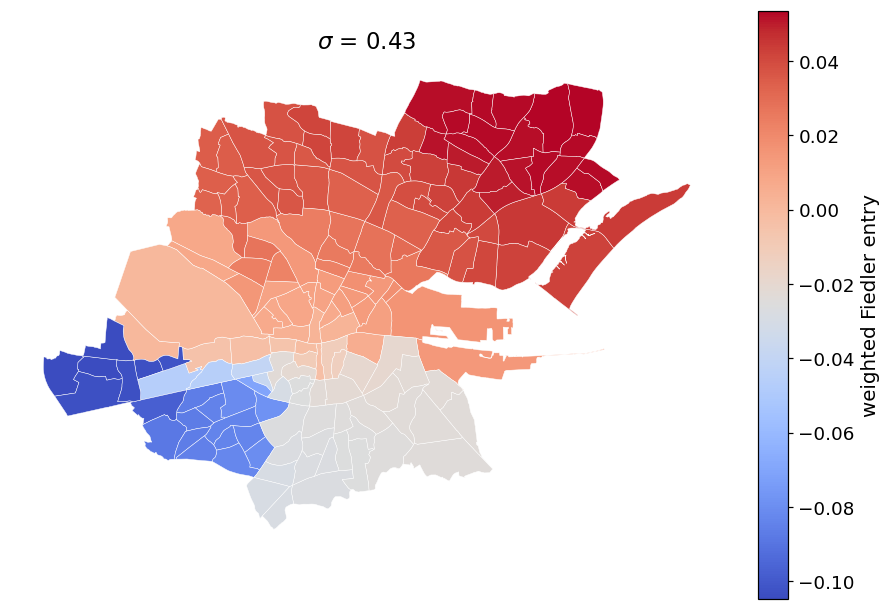

In [47]:
# Same contiguity edges as before, now carrying a weight between 0 and 1.
# Returns the weight matrix, the Ncut Fiedler vector and lambda_2, which is the
# health check: if lambda_2 has collapsed to zero the answer is meaningless.
def weighted_fiedler(sigma):
    W = np.zeros((len(gdf), len(gdf)))
    for i, j in G_ed.edges():
        W[i, j] = W[j, i] = np.exp(-((z[i] - z[j]) ** 2) / (2 * sigma ** 2))
    Dw = np.diag(W.sum(axis=1))
    vals, vecs = eigh(Dw - W, Dw)
    return W, vecs[:, 1], vals[1]


W, f_weighted, lam2 = weighted_fiedler(SIGMA)
gdf["weighted"] = f_weighted

print(f"edge weights: min {W[W > 0].min():.2e}, median {np.median(W[W > 0]):.3f}, max {W[W > 0].max():.3f}")
print(f"lambda_2 = {lam2:.3e}")
if lam2 < 1e-9:
    # Small sigma pushes whole edges to zero. Once the weighted graph has come apart,
    # lambda_2 is zero and the second eigenvector is an arbitrary vector out of the
    # null space. The map still renders and none of it means anything.
    print("  ^ numerically zero. The weighted graph has fallen into pieces; SIGMA is too small.")

fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column="weighted", cmap="coolwarm", legend=True,
         edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"shrink": 0.6, "label": "weighted Fiedler entry"})
ax.set_axis_off()
ax.set_title(rf"$\sigma$ = {SIGMA:.2f}")
plt.show()

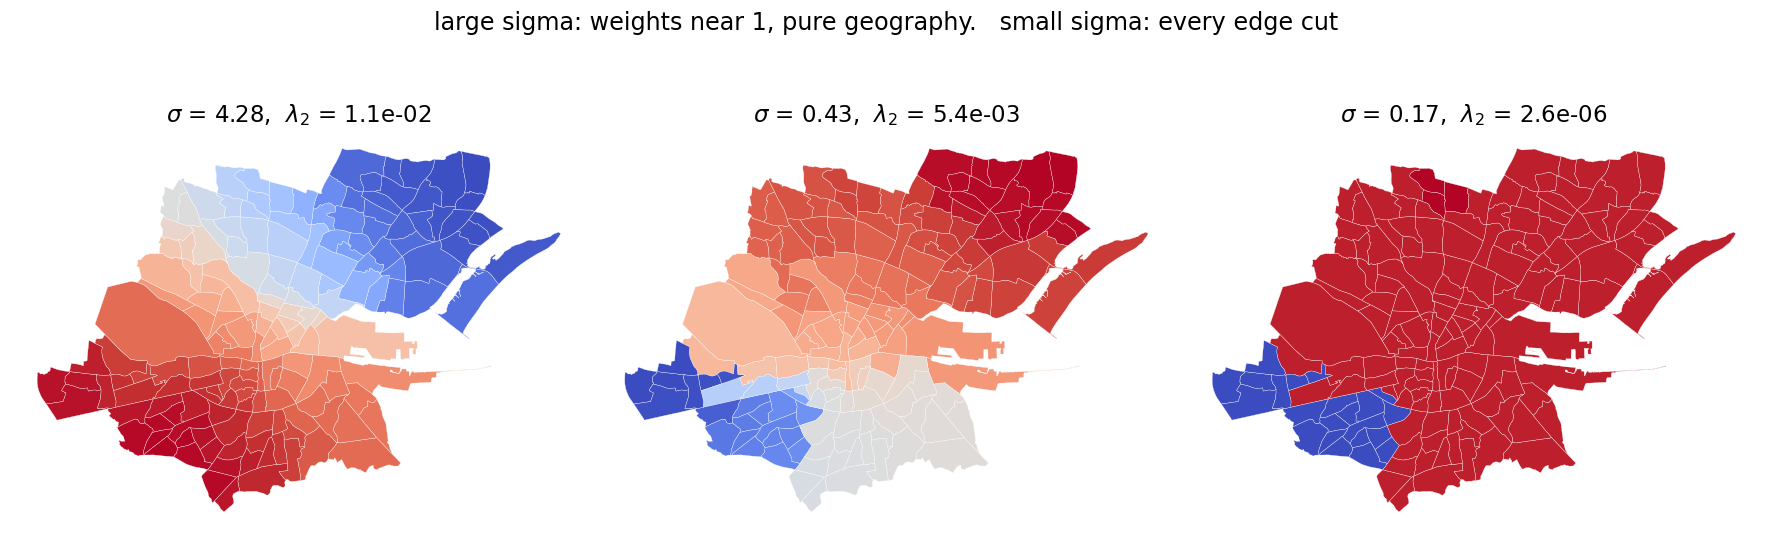

In [48]:
# Three values of sigma over the same graph, with lambda_2 printed on each panel.
# 0.4 rather than 0.1 because below roughly 0.3 x the median edge difference this
# particular graph separates into components and lambda_2 collapses to zero.
sigmas = [SIGMA * 10, SIGMA, SIGMA * 0.4]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, s in zip(axes, sigmas):
    _, f, lam = weighted_fiedler(s)
    gdf.assign(_f=f).plot(column="_f", cmap="coolwarm", ax=ax,
                          edgecolor="white", linewidth=0.2)
    ax.set_axis_off()
    ax.set_title(rf"$\sigma$ = {s:.2f},  $\lambda_2$ = {lam:.1e}")
fig.suptitle("large sigma: weights near 1, pure geography.   small sigma: every edge cut")
plt.show()

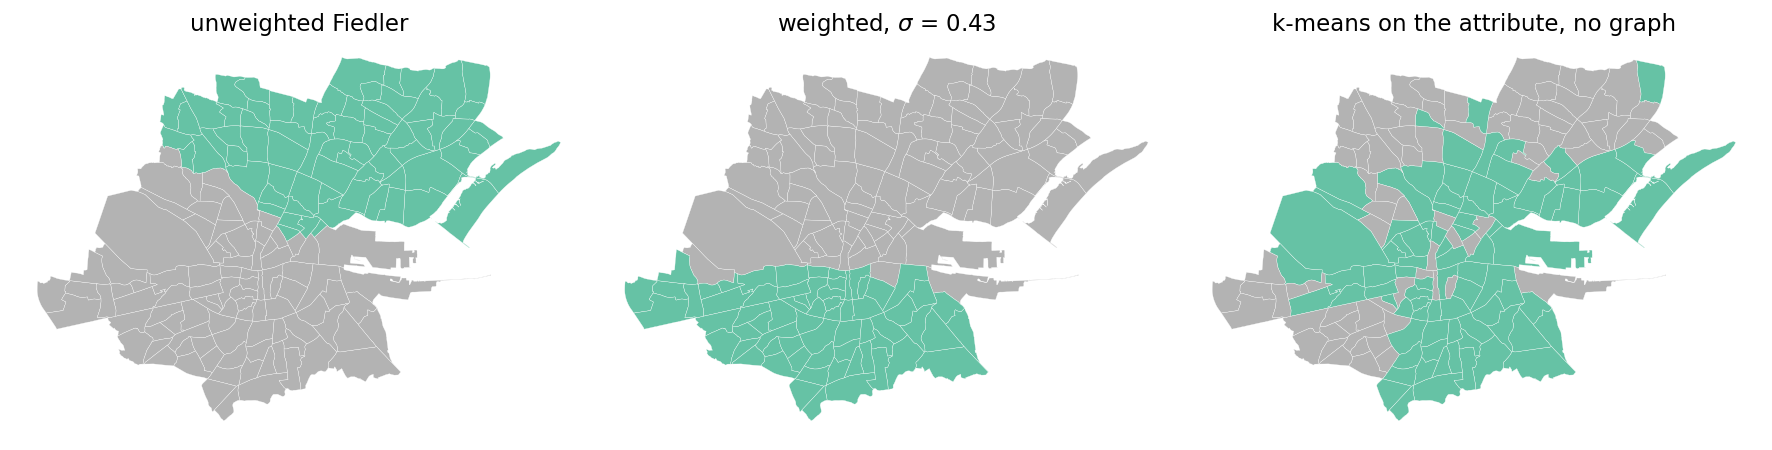

In [49]:
from sklearn.cluster import KMeans

# Three ways to cut the same city into two: geometry only, geometry plus attribute,
# and attribute only with no graph at all.
labels_unweighted = (gdf["fiedler"].to_numpy() > 0).astype(int)
labels_weighted = (f_weighted > 0).astype(int)
labels_kmeans = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(z.reshape(-1, 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, lab, title in [(axes[0], labels_unweighted, "unweighted Fiedler"),
                       (axes[1], labels_weighted, rf"weighted, $\sigma$ = {SIGMA:.2f}"),
                       (axes[2], labels_kmeans, "k-means on the attribute, no graph")]:
    gdf.assign(_l=lab).plot(column="_l", categorical=True, cmap="Set2", ax=ax,
                            edgecolor="white", linewidth=0.2)
    ax.set_axis_off()
    ax.set_title(title)
plt.show()

In [50]:
# How far the attribute actually moved the boundary, ED by ED.
import pandas as pd

print(pd.crosstab(pd.Series(labels_unweighted, name="unweighted"),
                  pd.Series(labels_weighted, name="weighted")))

weighted     0   1
unweighted        
0            0  68
1           66  28


In [51]:
# Session 2 picks these up in its section 0. If this cell is skipped, Session 2
# recomputes the same quantities itself and nothing is lost.
np.savez(
    DATA / "session1_state.npz",
    ed_names=gdf["ED_ENGLISH"].to_numpy(dtype=object),
    attribute=raw,
    z=z,
    sigma=SIGMA,
    fiedler=gdf["fiedler"].to_numpy(),
    labels_unweighted=labels_unweighted,
    labels_weighted=labels_weighted,
    labels_kmeans=labels_kmeans,
    allow_pickle=True,
)
print("wrote", (DATA / "session1_state.npz").resolve())

wrote C:\Users\KnoxA\data\session1_state.npz


## 8. Braess 

Read this afterwards. Four nodes, 4000 drivers, travel times in minutes.

In [52]:
DRIVERS = 4000

# Braess's paradox on the standard four-node network.
# s -> v costs t/100 minutes with t drivers on it; v -> t is a flat 45 whatever the load.
# The lower route is the mirror image. Adding a free v -> w link gives every single
# driver a better response than the one they had, and all 4000 of them take it.
def travel_time(flow_upper, flow_lower):
    return flow_upper / 100 + 45, flow_lower / 100 + 45


without = travel_time(DRIVERS / 2, DRIVERS / 2)[0]
with_extra = DRIVERS / 100 + 0 + DRIVERS / 100

print(f"two routes, 2000 each  : {without:.0f} minutes")
print(f"plus a free v->w link  : {with_extra:.0f} minutes")
print(f"everyone loses {with_extra - without:.0f} minutes by gaining an option")

two routes, 2000 each  : 65 minutes
plus a free v->w link  : 80 minutes
everyone loses 15 minutes by gaining an option


In [53]:
def equilibrium(latency, demand, iters=2000):
    """User equilibrium by Frank-Wolfe in path-flow space. latency: {edge: (a, b)}
    for a travel time a + b * flow. Returns the common cost on the used routes."""
    g = nx.DiGraph(list(latency))
    if "s" not in g or "t" not in g or not nx.has_path(g, "s", "t"):
        return None
    paths = [tuple(p) for p in nx.all_simple_paths(g, "s", "t")]
    index = {e: k for k, e in enumerate(latency)}
    P = np.zeros((len(paths), len(latency)))
    for r, path in enumerate(paths):
        for e in zip(path, path[1:]):
            P[r, index[e]] = 1.0
    a = np.array([latency[e][0] for e in latency], float)
    b = np.array([latency[e][1] for e in latency], float)

    f = np.zeros(len(paths))
    f[0] = demand
    for _ in range(iters):
        x = P.T @ f
        target = np.zeros_like(f)
        target[np.argmin(P @ (a + b * x))] = demand      # all-or-nothing step
        d = P.T @ (target - f)
        denom = b @ (d * d)                              # exact line search: linear
        if denom <= 0:                                   # latencies make the
            gamma = 1.0                                  # Beckmann objective a
        else:                                            # quadratic in gamma
            gamma = min(1.0, max(0.0, -(d @ (a + b * x)) / denom))
        if gamma == 0.0:
            break
        f = f + gamma * (target - f)

    x = P.T @ f
    return float((P @ (a + b * x))[f > 1e-6].min())


# One copy of the four-node trap, with the node names passed in so it can be reused.
def gadget(s_, v, w, m):
    return {(s_, v): (0.0, 0.01), (v, m): (45.0, 0.0),
            (s_, w): (45.0, 0.0), (w, m): (0.0, 0.01),
            (v, w): (0.0, 0.0)}


# Two copies of the same trap in series, then close each edge in turn and see
# which closures make everybody faster.
network = {**gadget("s", "v", "w", "m"), **gadget("m", "p", "q", "t")}
base = equilibrium(network, DRIVERS)

# Frank-Wolfe's tail is slow, so read these to about a tenth of a minute.
print(f"as built: {base:.2f} minutes\n")
for edge in list(network):
    trial = equilibrium({k: v for k, v in network.items() if k != edge}, DRIVERS)
    if trial is None:
        print(f"  close {str(edge):12s}  disconnects the network")
    else:
        print(f"  close {str(edge):12s}  {trial:7.2f}  ({trial - base:+6.2f})")

as built: 160.00 minutes

  close ('s', 'v')     165.00  ( +5.00)
  close ('v', 'm')     160.00  ( +0.00)
  close ('s', 'w')     160.00  ( +0.00)
  close ('w', 'm')     165.00  ( +5.00)
  close ('v', 'w')     144.96  (-15.04)
  close ('m', 'p')     165.00  ( +5.00)
  close ('p', 't')     160.00  ( +0.00)
  close ('m', 'q')     160.00  ( +0.00)
  close ('q', 't')     165.00  ( +5.00)
  close ('p', 'q')     144.96  (-15.04)
